# Libs

In [182]:
# https://www.kaggle.com/datasets/yasserh/titanic-dataset/data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,  roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

# Load the dataset
data = pd.read_csv('titanic.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [183]:
print(data.info()) # shows columns names, number of non-null values and data type
print(data.isnull().sum()) # shows number of null values in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

# Feature Selection/Creation

Handled feature creation/selection first because 'Age' column will be filled based on 'Title'(to be created) column .

### Why?
Because I can use the passenger's title appeared in 'Name' column to determin the missing age better than randomly filling it with median of the whole column and no the median of the title itself.

In [184]:
df = data.copy()

In [185]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+\.)', expand=False)
df['Title'].unique()

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Don.', 'Rev.', 'Dr.', 'Mme.',
       'Ms.', 'Major.', 'Lady.', 'Sir.', 'Mlle.', 'Col.', 'Capt.',
       'Countess.', 'Jonkheer.'], dtype=object)

In [186]:
df['Title'] = df['Title'].replace(['Sir.'], 'Mr.')
df['Title'] = df['Title'].replace(['Mme.', 'Lady.', 'Countess.'], 'Mrs.')
df['Title'] = df['Title'].replace(['Ms.', 'Mlle.'], 'Miss.')
df['Title'] = df['Title'].replace(['Dr.', 'Rev.', 'Major.', 'Col.', 'Capt.', 'Jonkheer.', 'Don.'], 'Rare')
df['Title'].unique()

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Rare'], dtype=object)

In [187]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.


In [188]:
df['Surname'] = df['Name'].apply(lambda x: x.split(',')[0].strip())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Family_Survival'] = 0.5

# Group by Surname
for grp, grp_df in df.groupby(['Surname', 'FamilySize']):
    if len(grp_df) > 1:
        if (grp_df['Survived'] == 1).any():
            df.loc[grp_df.index, 'Family_Survival'] = 1
        elif (grp_df['Survived'] == 0).any():
            df.loc[grp_df.index, 'Family_Survival'] = 0

# Group by Ticket (Catch friends/groups who aren't family)
for grp, grp_df in df.groupby('Ticket'):
    if len(grp_df) > 1:
        for ind in grp_df.index:
            if df.loc[ind, 'Family_Survival'] == 0.5: # Only update if unknown
                if (grp_df.drop(ind)['Survived'] == 1).any():
                    df.loc[ind, 'Family_Survival'] = 1
                elif (grp_df.drop(ind)['Survived'] == 0).any():
                    df.loc[ind, 'Family_Survival'] = 0

# Handle Missing Values


In [189]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [190]:
df['Agе​'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median')) # cus mean is sensitive to outliers.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [191]:
df[['Agе​', 'Embarked']].isnull().sum()

,0
Agе​,0
Embarked,0


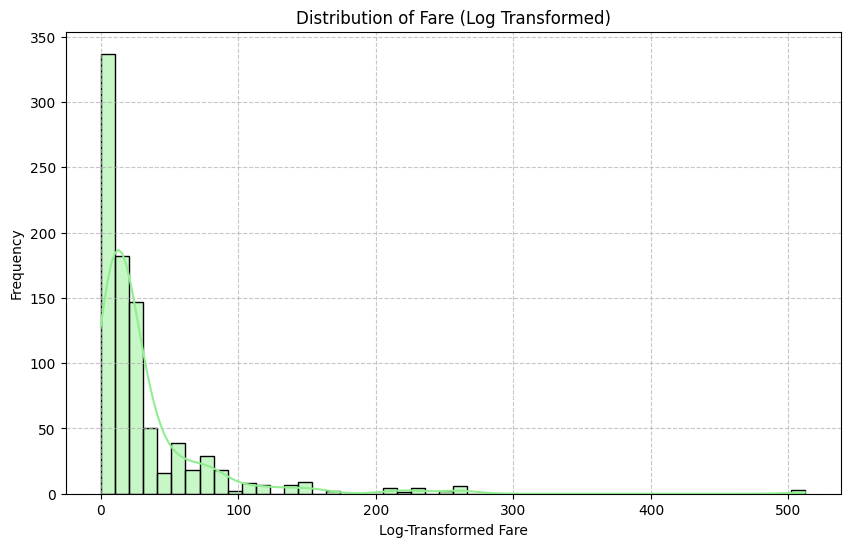

In [192]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Fare (Log Transformed)')
plt.xlabel('Log-Transformed Fare')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [193]:
df['Fare'] = np.log1p(df['Fare'])

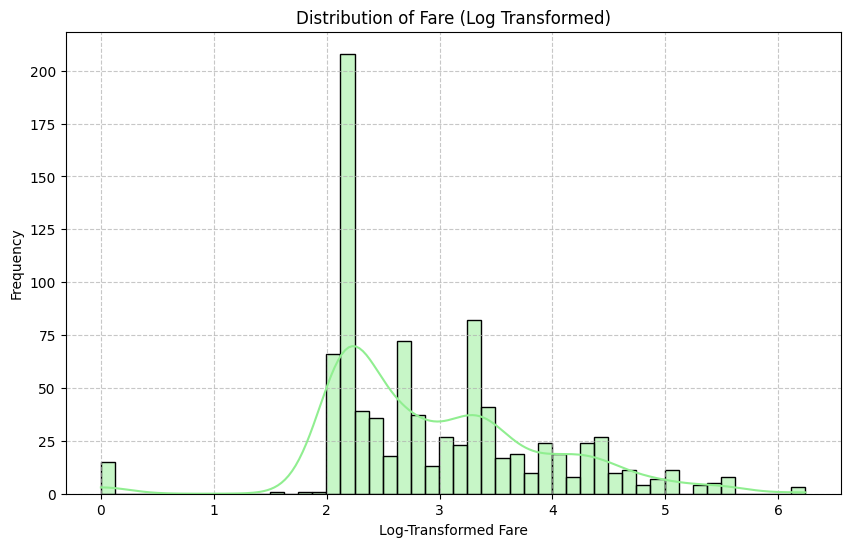

In [194]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Fare (Log Transformed)')
plt.xlabel('Log-Transformed Fare')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Encoding


Based on the unique values, I'll choose the encoding method.



Binary mapping for 'Sex' column.

In [195]:
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0}).astype(int)

One-hot Encoding

In [196]:
df = pd.get_dummies(df, columns=['Title', 'Embarked'], drop_first=True)

In [197]:
selected_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "FamilySize", "Family_Survival",
                     "Title_Miss.", "Title_Mr.", "Title_Mrs.", "Title_Rare",
                     "Embarked_Q", "Embarked_S"]

In [198]:
df[selected_features].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Family_Survival,Title_Miss.,Title_Mr.,Title_Mrs.,Title_Rare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,2.110213,2,0.0,False,True,False,False,False,True
1,1,1,38.0,1,0,4.280593,2,0.5,False,False,True,False,False,False
2,3,1,26.0,0,0,2.188856,1,0.5,True,False,False,False,False,True
3,1,1,35.0,1,0,3.990834,2,1.0,False,False,True,False,False,True
4,3,0,35.0,0,0,2.202765,1,1.0,False,True,False,False,False,True


# Spliting



In [199]:
X = df[selected_features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(y.unique())

Training set size: (712, 14)
Testing set size: (179, 14)
[0 1]


# Scaling


In [200]:
sc = StandardScaler()
cols_to_scale = ['Fare']

X_train[cols_to_scale] = sc.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = sc.transform(X_test[cols_to_scale])

# Training

In [201]:
model = RandomForestClassifier(
    n_estimators=300,
    criterion='entropy',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

### Actual vs Predicted comparison


In [202]:
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc * 100:.2f}%")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

Accuracy: 85.47%
------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.88      0.88      0.88       110
       Survived       0.81      0.81      0.81        69

       accuracy                           0.85       179
      macro avg       0.85      0.85      0.85       179
   weighted avg       0.85      0.85      0.85       179



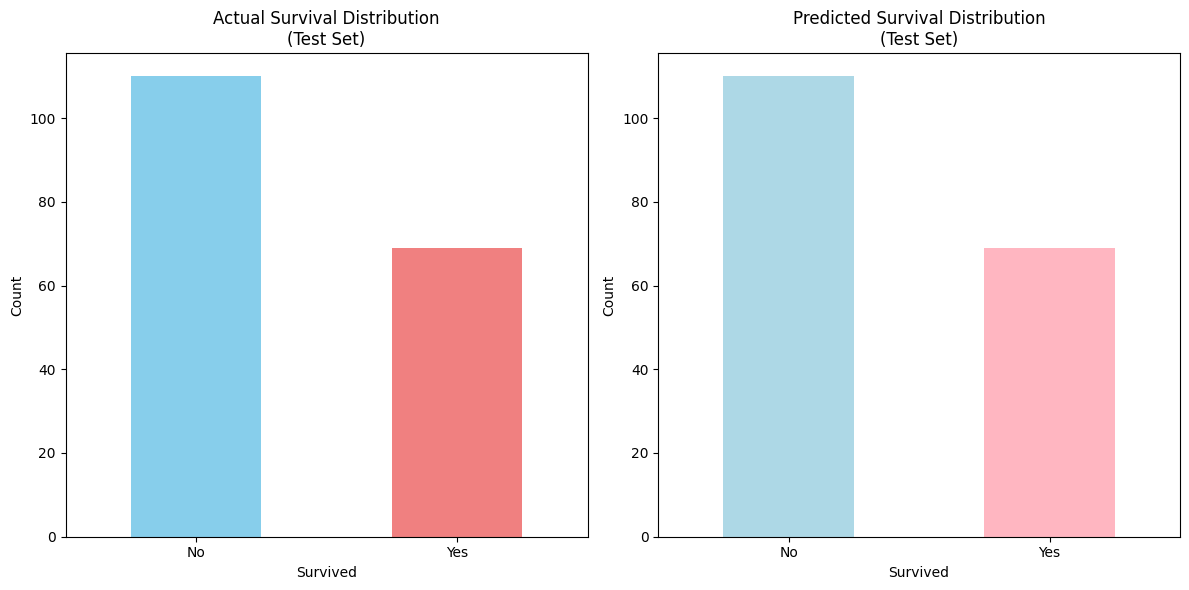

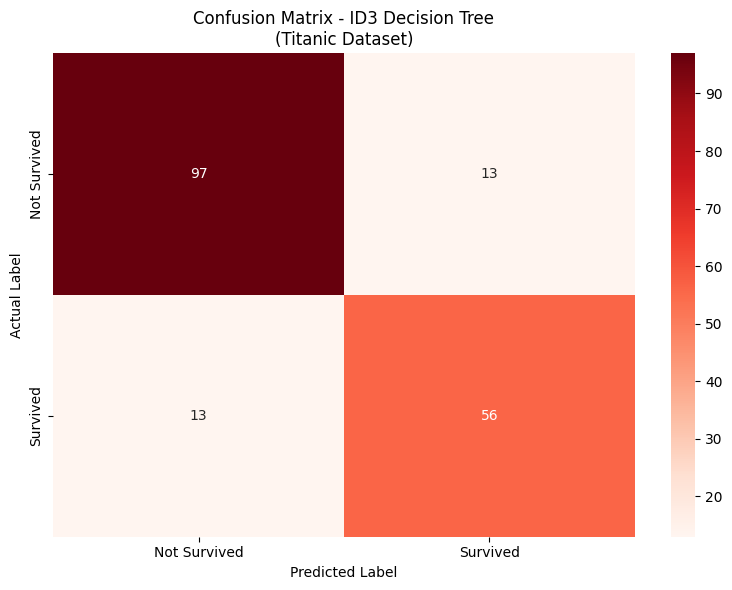

In [203]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Correct': y_test.values == y_pred
})

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
comparison_df['Actual'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Actual Survival Distribution\n(Test Set)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

plt.subplot(1, 2, 2)
comparison_df['Predicted'].value_counts().plot(kind='bar', color=['lightblue', 'lightpink'])
plt.title('Predicted Survival Distribution\n(Test Set)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.savefig('id3_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


# ===============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - ID3 Decision Tree\n(Titanic Dataset)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.show()

In [204]:
# Pclass	Sex	Age	SibSp	Parch	Fare	Title_Miss.	Title_Mr.	Title_Mrs.	Title_Rare	Embarked_Q	Embarked_S
def predict_user_input(p_class, sex, age, sibsp, parch, fare, embarked, title):
    print("\nEnter passenger details to predict survival:")
    try:
        # Create DataFrame with Initial Features
        input_data = {
            'Pclass': [p_class],
            'Sex': [1 if sex == 'female' else 0], # Map female:1, male:0
            'Age': [age],
            'SibSp': [sibsp],
            'Parch': [parch],
            'Fare': [fare]
        }

        # (One-Hot Encoding)
        # Initialize all dummy columns to 0
        dummy_cols = ['Title_Miss.', 'Title_Mr.', 'Title_Mrs.', 'Title_Rare', 'Embarked_Q', 'Embarked_S']
        for col in dummy_cols:
            input_data[col] = [0]

        # Set Title dummy
        t_clean = title.replace('.', '')
        title_map = {
            'Miss': 'Title_Miss.',
            'Mr': 'Title_Mr.',
            'Mrs': 'Title_Mrs.',
            'Rare': 'Title_Rare'
        }
        if t_clean in title_map:
            input_data[title_map[t_clean]] = [1]

        # Set Embarked dummy
        emb_map = {'Q': 'Embarked_Q', 'S': 'Embarked_S'}
        if embarked in emb_map:
            input_data[emb_map[embarked]] = [1]

        # Create DataFrame & Ensure correct column order
        model_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Family_Survival', 'Title_Miss.', 'Title_Mr.', 'Title_Mrs.', 'Title_Rare', 'Embarked_Q', 'Embarked_S']
        input_df = pd.DataFrame(input_data)

        # Add FamilySize and Family_Survival as they are part of selected_features
        # For single user input, these will be based on the single input
        input_df['FamilySize'] = input_df['SibSp'] + input_df['Parch'] + 1
        input_df['Family_Survival'] = 0.5 # Default value, can be refined if needed for single prediction

        input_df = input_df[model_cols]

        # Apply log transformation to 'Fare' before scaling
        input_df[['Fare']] = np.log1p(input_df[['Fare']])

        # Scale 'Fare' as per training (after log transformation)
        input_df[['Fare']] = sc.transform(input_df[['Fare']])

        # Predict
        prediction = model.predict(input_df)[0]
        pred_proba = model.predict_proba(input_df)[0]

        outcome = "Survived" if prediction == 1 else "Did Not Survive"
        print(f"\nPrediction: {outcome}")
        print(f"Probability of Survival: {pred_proba[1]:.2%}")
        print(input_df.head())

    except Exception as e:
        print(f"An error occurred: {e}")

In [205]:
predict_user_input(
    p_class=1,
    sex='female',
    age=38.0,
    sibsp=1,
    parch=0,
    fare=71.2833,
    embarked='C',
    title='Mrs.'
)



Enter passenger details to predict survival:

Prediction: Survived
Probability of Survival: 97.78%
   Pclass  Sex   Age  SibSp  Parch      Fare  FamilySize  Family_Survival  \
0       1    1  38.0      1      0  1.358397           2              0.5   

   Title_Miss.  Title_Mr.  Title_Mrs.  Title_Rare  Embarked_Q  Embarked_S  
0            0          0           1           0           0           0  
